In [ ]:
import io
import contextlib
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import torch
import wandb

import sys
import os
sys.path.append(os.path.abspath("../../"))
from QNeuralForecast.dlinear import QDLinear
from QNeuralForecast.patchtst import QPatchTST
from QNeuralForecast.timesnet import QTimesNet
from QNeuralForecast.nhits import QNHITS
from neuralforecast.models import DLinear, NHITS, PatchTST, TimesNet

from neuralforecast import NeuralForecast
from pytorch_lightning.loggers import WandbLogger
from neuralforecast.losses.numpy import mae, mse, rmse, mape, smape, mase


@contextlib.contextmanager
def suppress_output():
    """Redirect stdout and stderr to /dev/null during model training."""
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield


def set_global_seed(seed: int):
    """Fix all global random sources for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


In [93]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)
df = df.sort_values(["Store", "Date"])

delta_days = (max(df["Date"]) - min(df["Date"])).days
train_days = int(delta_days * 0.8)
split_date = min(df["Date"]) + np.timedelta64(train_days,"D")

train_df = df[df["Date"] < split_date].copy()
test_df  = df[df["Date"] >= split_date].copy()

HORIZON = (max(df["Date"]) - np.datetime64(split_date)).days

In [94]:
# ── Experiment label ─────────────────────────────────────────────────────────
# Change this before each run to keep results separated in W&B.
# e.g. "dev", "hpo_test", "final"
EXPERIMENT = "dev"

# --- Classical models (no circuit_device param) — trained once as baseline ---
CLASSICAL_MODEL_CLASSES = [DLinear, NHITS, PatchTST, TimesNet]

# --- Quantum models (have circuit_device param) — trained once per device ---
QUANTUM_MODEL_CLASSES = [QDLinear, QNHITS, QPatchTST, QTimesNet]

# --- Devices to compare ---
# Each key becomes a run label in results; value is passed as circuit_device=...
QUANTUM_DEVICES = {
    "ideal":     "default.qubit",   # noise-free statevector simulation
    "noisy_sim": "default.mixed",   # mixed-state sim — add depolarising noise in circuit
    # "real_nisq": "qiskit.ibm.remote",  # actual hardware (requires IBM account + credentials)
}

# Combined for HPO (shared best_params applied to all model types)
model_classes = CLASSICAL_MODEL_CLASSES + QUANTUM_MODEL_CLASSES


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# --- Hyperparameter search space ---
HYPERPARAM_GRID = {
    "input_size":    [100, 200, 400],
    "max_steps":     [50, 100, 300],
    "learning_rate": (1e-4, 1e-1),   # log-uniform range
    "scaler_type":   ["standard", "robust", "minmax", "identity"],
}

def objective(trial):
    input_size    = trial.suggest_categorical("input_size",    HYPERPARAM_GRID["input_size"])
    max_steps     = trial.suggest_categorical("max_steps",     HYPERPARAM_GRID["max_steps"])
    learning_rate = trial.suggest_float("learning_rate", *HYPERPARAM_GRID["learning_rate"], log=True)
    scaler_type   = trial.suggest_categorical("scaler_type",   HYPERPARAM_GRID["scaler_type"])

    trial_models = [
        cls(
            h=HORIZON,
            input_size=input_size,
            max_steps=max_steps,
            learning_rate=learning_rate,
            scaler_type=scaler_type,
            start_padding_enabled=True,
            # Disable logging during HPO — Optuna tracks CV MAE, training curves not needed
            logger=False,
        )
        for cls in model_classes
    ]

    nf_trial = NeuralForecast(models=trial_models, freq="D")
    with suppress_output():
        cv = nf_trial.cross_validation(
            train_df, n_windows=4, step_size=100,
            verbose=False, refit=False,
            id_col="Store", time_col="Date", target_col="Sales"
        )

    model_cols = [c for c in cv.columns if c not in ["Store", "Date", "Sales", "cutoff"]]
    avg_mae = float(np.mean([mae(cv["Sales"].values, cv[m].values) for m in model_cols]))
    return avg_mae

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="rossmann_hpo",
)
study.optimize(objective, n_trials=20, n_jobs=1, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest CV MAE : {study.best_value:.4f}")
print(f"Best params : {best_params}")


Best CV MAE : 1733.2918
Best params : {'input_size': 100, 'max_steps': 300, 'learning_rate': 0.0002404111090989083, 'scaler_type': 'standard'}

 number       value  params_input_size  params_max_steps  params_learning_rate params_scaler_type
     17 1733.291787                100               300              0.000240           standard
     11 1769.156391                100               300              0.000584           standard
     12 1779.324506                100               300              0.000639           standard
      5 1782.494377                100               300              0.000652           standard
     10 1806.043012                100               300              0.000786           standard
     13 1875.390777                100               300              0.001183           standard
     14 1925.378284                100               300              0.000328           identity
      6 1937.205823                200                50              0.

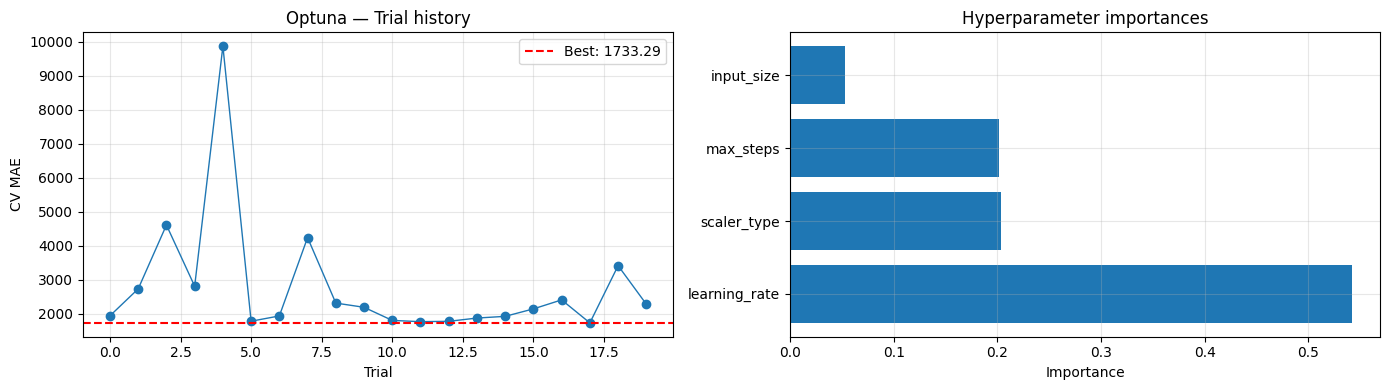

In [96]:
# --- HPO results summary ---
print(f"Best CV MAE : {study.best_value:.4f}")
print(f"Best params : {study.best_params}\n")

trials_df = study.trials_dataframe().sort_values("value")
print(trials_df[["number", "value", "params_input_size", "params_max_steps",
                  "params_learning_rate", "params_scaler_type"]].to_string(index=False))

# Plot trial history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot([t.number for t in study.trials],
             [t.value for t in study.trials], marker='o', linewidth=1)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f"Best: {study.best_value:.2f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV MAE")
axes[0].set_title("Optuna — Trial history")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter importances")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
SEEDS = [0, 1, 2]
#SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# all_seed_forecasts: {run_label -> [seed_fc_df, ...]}
# run_label = "classical" for classical models, or the device key for quantum models
all_seed_forecasts = {}

# ── 1. Classical models (device-independent, trained once) ──────────────────
if CLASSICAL_MODEL_CLASSES:
    print("═" * 60)
    print("CLASSICAL MODELS")
    print("═" * 60)
    classical_forecasts = []
    for seed in SEEDS:
        print(f"\n  --- seed {seed} ---")
        set_global_seed(seed)
        seed_models = [
            cls(
                h=HORIZON,
                input_size=best_params["input_size"],
                max_steps=best_params["max_steps"],
                learning_rate=best_params["learning_rate"],
                scaler_type=best_params["scaler_type"],
                start_padding_enabled=True,
                random_seed=seed,
                early_stop_patience_steps=5,
                logger=WandbLogger(
                    project="qtsf",
                    name=f"{EXPERIMENT}/classical/{cls.__name__}/seed_{seed}",
                    group=f"{EXPERIMENT}/classical/{cls.__name__}",
                    tags=[EXPERIMENT, "classical", "training", cls.__name__],
                ),
            )
            for cls in CLASSICAL_MODEL_CLASSES
        ]
        nf = NeuralForecast(models=seed_models, freq="D")
        with suppress_output():
            nf.fit(train_df, id_col="Store", time_col="Date", target_col="Sales", val_size=HORIZON)
            fc = nf.predict().reset_index()
        classical_forecasts.append(fc)
        print(f"  Forecast range: {fc['Date'].min().date()} → {fc['Date'].max().date()}")
    all_seed_forecasts["classical"] = classical_forecasts
    print(f"\n  ✓ Classical: {len(SEEDS)} seeds done.")

# ── 2. Quantum models (one seed loop per device) ────────────────────────────
if QUANTUM_MODEL_CLASSES:
    for dev_label, dev_name in QUANTUM_DEVICES.items():
        print("\n" + "═" * 60)
        print(f"QUANTUM MODELS  |  device: {dev_label}  ({dev_name})")
        print("═" * 60)
        dev_forecasts = []
        for seed in SEEDS:
            print(f"\n  --- seed {seed} ---")
            set_global_seed(seed)
            seed_models = [
                cls(
                    h=HORIZON,
                    input_size=best_params["input_size"],
                    max_steps=best_params["max_steps"],
                    learning_rate=best_params["learning_rate"],
                    scaler_type=best_params["scaler_type"],
                    start_padding_enabled=True,
                    random_seed=seed,
                    early_stop_patience_steps=5,
                    circuit_device=dev_name,
                    logger=WandbLogger(
                        project="qtsf",
                        name=f"{EXPERIMENT}/{dev_label}/{cls.__name__}/seed_{seed}",
                        group=f"{EXPERIMENT}/{dev_label}/{cls.__name__}",
                        tags=[EXPERIMENT, dev_label, "training", cls.__name__],
                    ),
                )
                for cls in QUANTUM_MODEL_CLASSES
            ]
            nf = NeuralForecast(models=seed_models, freq="D")
            with suppress_output():
                nf.fit(train_df, id_col="Store", time_col="Date", target_col="Sales", val_size=HORIZON)
                fc = nf.predict().reset_index()
            dev_forecasts.append(fc)
            print(f"  Forecast range: {fc['Date'].min().date()} → {fc['Date'].max().date()}")
        all_seed_forecasts[dev_label] = dev_forecasts
        print(f"\n  ✓ {dev_label}: {len(SEEDS)} seeds done.")

print(f"\nAll runs complete. Run labels: {list(all_seed_forecasts.keys())}")


Seed set to 0


════════════════════════════════════════════════════════════
CLASSICAL MODELS
════════════════════════════════════════════════════════════

  --- seed 0 ---


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │ 18.0 K │ train │     0 │
│ 5 │ linear_season │ Linear        │ 18.0 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 36.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 36.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

`Trainer.fit` stopped: `max_steps=300` reached.


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

  Forecast range: 2015-01-18 → 2015-07-30

  ✓ Classical: 3 seeds done.

All runs complete. Run labels: ['classical']


In [ ]:
y_train_global = train_df["Sales"].values
SEASONALITY = 7

# all_avg_results  : {run_label -> {model -> {metric -> float}}}  (seed-ensemble score)
# all_seed_results : {run_label -> {model -> {metric -> [per-seed floats]}}}
all_avg_results  = {}
all_seed_results = {}
all_avg_forecasts = {}  # {run_label -> avg_forecast_df}  — kept for store plots

for run_label, seed_forecasts in all_seed_forecasts.items():

    # --- Average forecasts across seeds ---
    model_names = [c for c in seed_forecasts[0].columns if c not in ["index", "Store", "Date"]]
    avg_forecasts = seed_forecasts[0][["Store", "Date"]].copy()
    for model in model_names:
        avg_forecasts[model] = np.mean([fc[model].values for fc in seed_forecasts], axis=0)
    all_avg_forecasts[run_label] = avg_forecasts

    comparison = test_df[["Store", "Date", "Sales"]].merge(
        avg_forecasts, on=["Store", "Date"], how="inner"
    )

    # --- Per-seed metrics ---
    seed_results = {m: {k: [] for k in ["MAE", "MSE", "RMSE", "MAPE", "MASE"]}
                    for m in model_names}
    for fc in seed_forecasts:
        comp_s = test_df[["Store", "Date", "Sales"]].merge(fc, on=["Store", "Date"], how="inner")
        for model in model_names:
            seed_results[model]["MAE" ].append(mae( comp_s["Sales"], comp_s[model]))
            seed_results[model]["MSE" ].append(mse( comp_s["Sales"], comp_s[model]))
            seed_results[model]["RMSE"].append(rmse(comp_s["Sales"], comp_s[model]))
            seed_results[model]["MAPE"].append(mape(comp_s["Sales"], comp_s[model]))
            seed_results[model]["MASE"].append(mase(comp_s["Sales"], comp_s[model],
                                                    y_train=y_train_global,
                                                    seasonality=SEASONALITY))

    # --- Ensemble (seed-averaged forecast) metrics ---
    avg_results = {}
    for model in model_names:
        avg_results[model] = {
            "MAE" : mae( comparison["Sales"], comparison[model]),
            "MSE" : mse( comparison["Sales"], comparison[model]),
            "RMSE": rmse(comparison["Sales"], comparison[model]),
            "MAPE": mape(comparison["Sales"], comparison[model]),
            "MASE": mase(comparison["Sales"], comparison[model],
                         y_train=y_train_global, seasonality=SEASONALITY),
        }

    all_avg_results [run_label] = avg_results
    all_seed_results[run_label] = seed_results

    # --- W&B logging (one run per model x device combination) ---
    for model in model_names:
        run = wandb.init(
            project="qtsf",
            name=f"{EXPERIMENT}/{run_label}/{model}",
            group=f"{EXPERIMENT}/{run_label}",
            tags=[EXPERIMENT, run_label, model],
        )
        log_dict: dict = {"model": model, "run_label": run_label, "experiment": EXPERIMENT}
        for metric_name, val in avg_results[model].items():
            log_dict[f"avg_{metric_name}"] = float(val)
        for metric_name, vals in seed_results[model].items():
            log_dict[f"mean_{metric_name}"] = float(np.mean(vals))
            log_dict[f"std_{metric_name}"]  = float(np.std(vals))
        run.log(log_dict)
        run.finish()

In [104]:
# ── Summary table ────────────────────────────────────────────────────────────
print("\nTest-set metrics  (seed-ensemble ★ | seeds mean ± std)")
print("─" * 70)
for run_label in all_avg_results:
    print(f"\n  [{run_label}]")
    for model in sorted(all_avg_results[run_label], key=lambda m: all_avg_results[run_label][m]["MAE"]):
        a = all_avg_results[run_label][model]
        s = all_seed_results[run_label][model]
        print(f"    {model}:")
        for metric in ["MAE", "MSE", "RMSE", "MAPE", "MASE"]:
            print(f"      {metric}: ★{a[metric]:.4f}  |  "
                  f"seeds {np.mean(s[metric]):.4f} ± {np.std(s[metric]):.4f}")


Test-set metrics  (seed-ensemble ★ | seeds mean ± std)
──────────────────────────────────────────────────────────────────────

  [classical]
    DLinear:
      MAE: ★1493.2830  |  seeds 1576.1833 ± 22.3218
      MSE: ★3888948.5824  |  seeds 4314916.1233 ± 72012.9477
      RMSE: ★1972.0417  |  seeds 2077.1652 ± 17.3415
      MAPE: ★0.2418  |  seeds 0.2537 ± 0.0032
      MASE: ★0.6301  |  seeds 0.6651 ± 0.0094


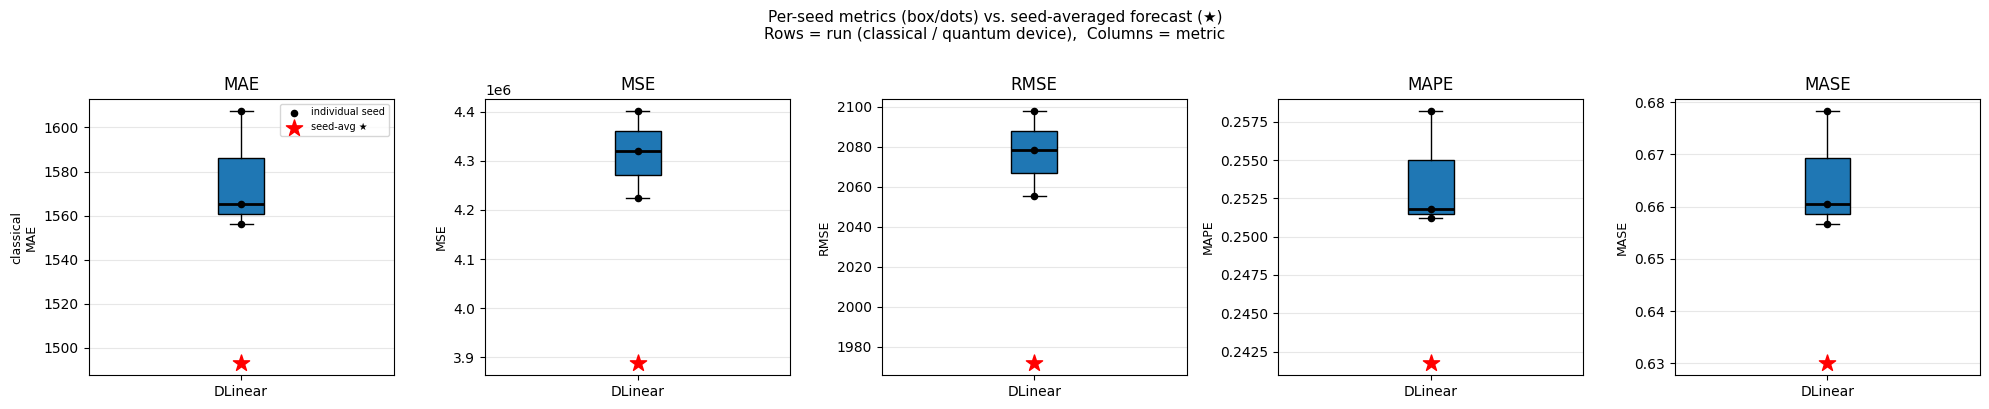

In [101]:
# ── Box plots: one row per run_label, one subplot per metric ─────────────────
metrics_to_plot = ["MAE", "MSE", "RMSE", "MAPE", "MASE"]
n_runs = len(all_seed_results)

fig, axes = plt.subplots(n_runs, len(metrics_to_plot),
                         figsize=(4 * len(metrics_to_plot), 4 * n_runs),
                         squeeze=False)
fig.suptitle(
    "Per-seed metrics (box/dots) vs. seed-averaged forecast (★)\n"
    "Rows = run (classical / quantum device),  Columns = metric",
    fontsize=11, y=1.01
)

for row, (run_label, seed_results) in enumerate(all_seed_results.items()):
    model_names = list(seed_results.keys())
    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row][col]
        data = [seed_results[m][metric] for m in model_names]
        ax.boxplot(data, tick_labels=model_names, patch_artist=True, notch=False,
                   medianprops=dict(color="black", linewidth=2))
        for i, values in enumerate(data, start=1):
            ax.scatter([i] * len(values), values, color="black", zorder=5, s=20,
                       label="individual seed" if (i == 1 and col == 0) else "")
        for i, m in enumerate(model_names, start=1):
            ax.scatter(i, all_avg_results[run_label][m][metric],
                       marker="*", color="red", zorder=6, s=150,
                       label="seed-avg ★" if (i == 1 and col == 0) else "")
        if col == 0:
            ax.set_ylabel(f"{run_label}\n{metric}", fontsize=9)
        else:
            ax.set_ylabel(metric, fontsize=9)
        if row == 0:
            ax.set_title(metric)
        ax.grid(True, axis="y", alpha=0.3)
        if col == 0:
            ax.legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()

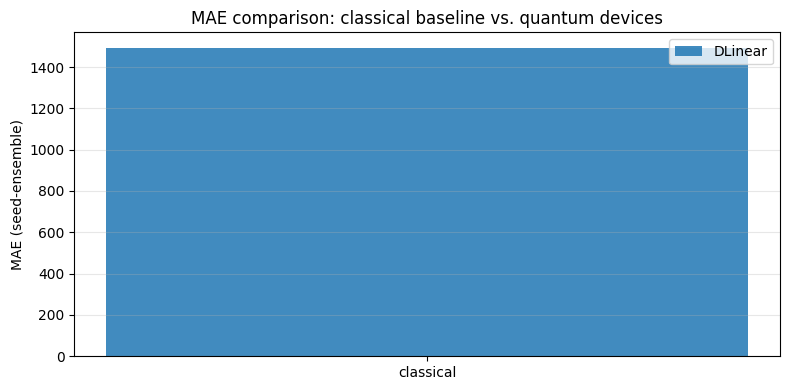

In [103]:
# ── MAE comparison bar chart across all runs ─────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, 2 * len(all_avg_results)), 4))
x = np.arange(len(all_avg_results))
run_labels = list(all_avg_results.keys())
all_model_names = sorted({m for r in all_avg_results.values() for m in r})
bar_width = 0.8 / len(all_model_names)

for j, model in enumerate(all_model_names):
    maes = [all_avg_results[rl].get(model, {}).get("MAE", float("nan"))
            for rl in run_labels]
    ax.bar(x + j * bar_width, maes, width=bar_width, label=model, alpha=0.85)

ax.set_xticks(x + bar_width * (len(all_model_names) - 1) / 2)
ax.set_xticklabels(run_labels)
ax.set_ylabel("MAE (seed-ensemble)")
ax.set_title("MAE comparison: classical baseline vs. quantum devices")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Top 5 stores (lowest avg error across all runs): [789, 794, 656, 208, 558]


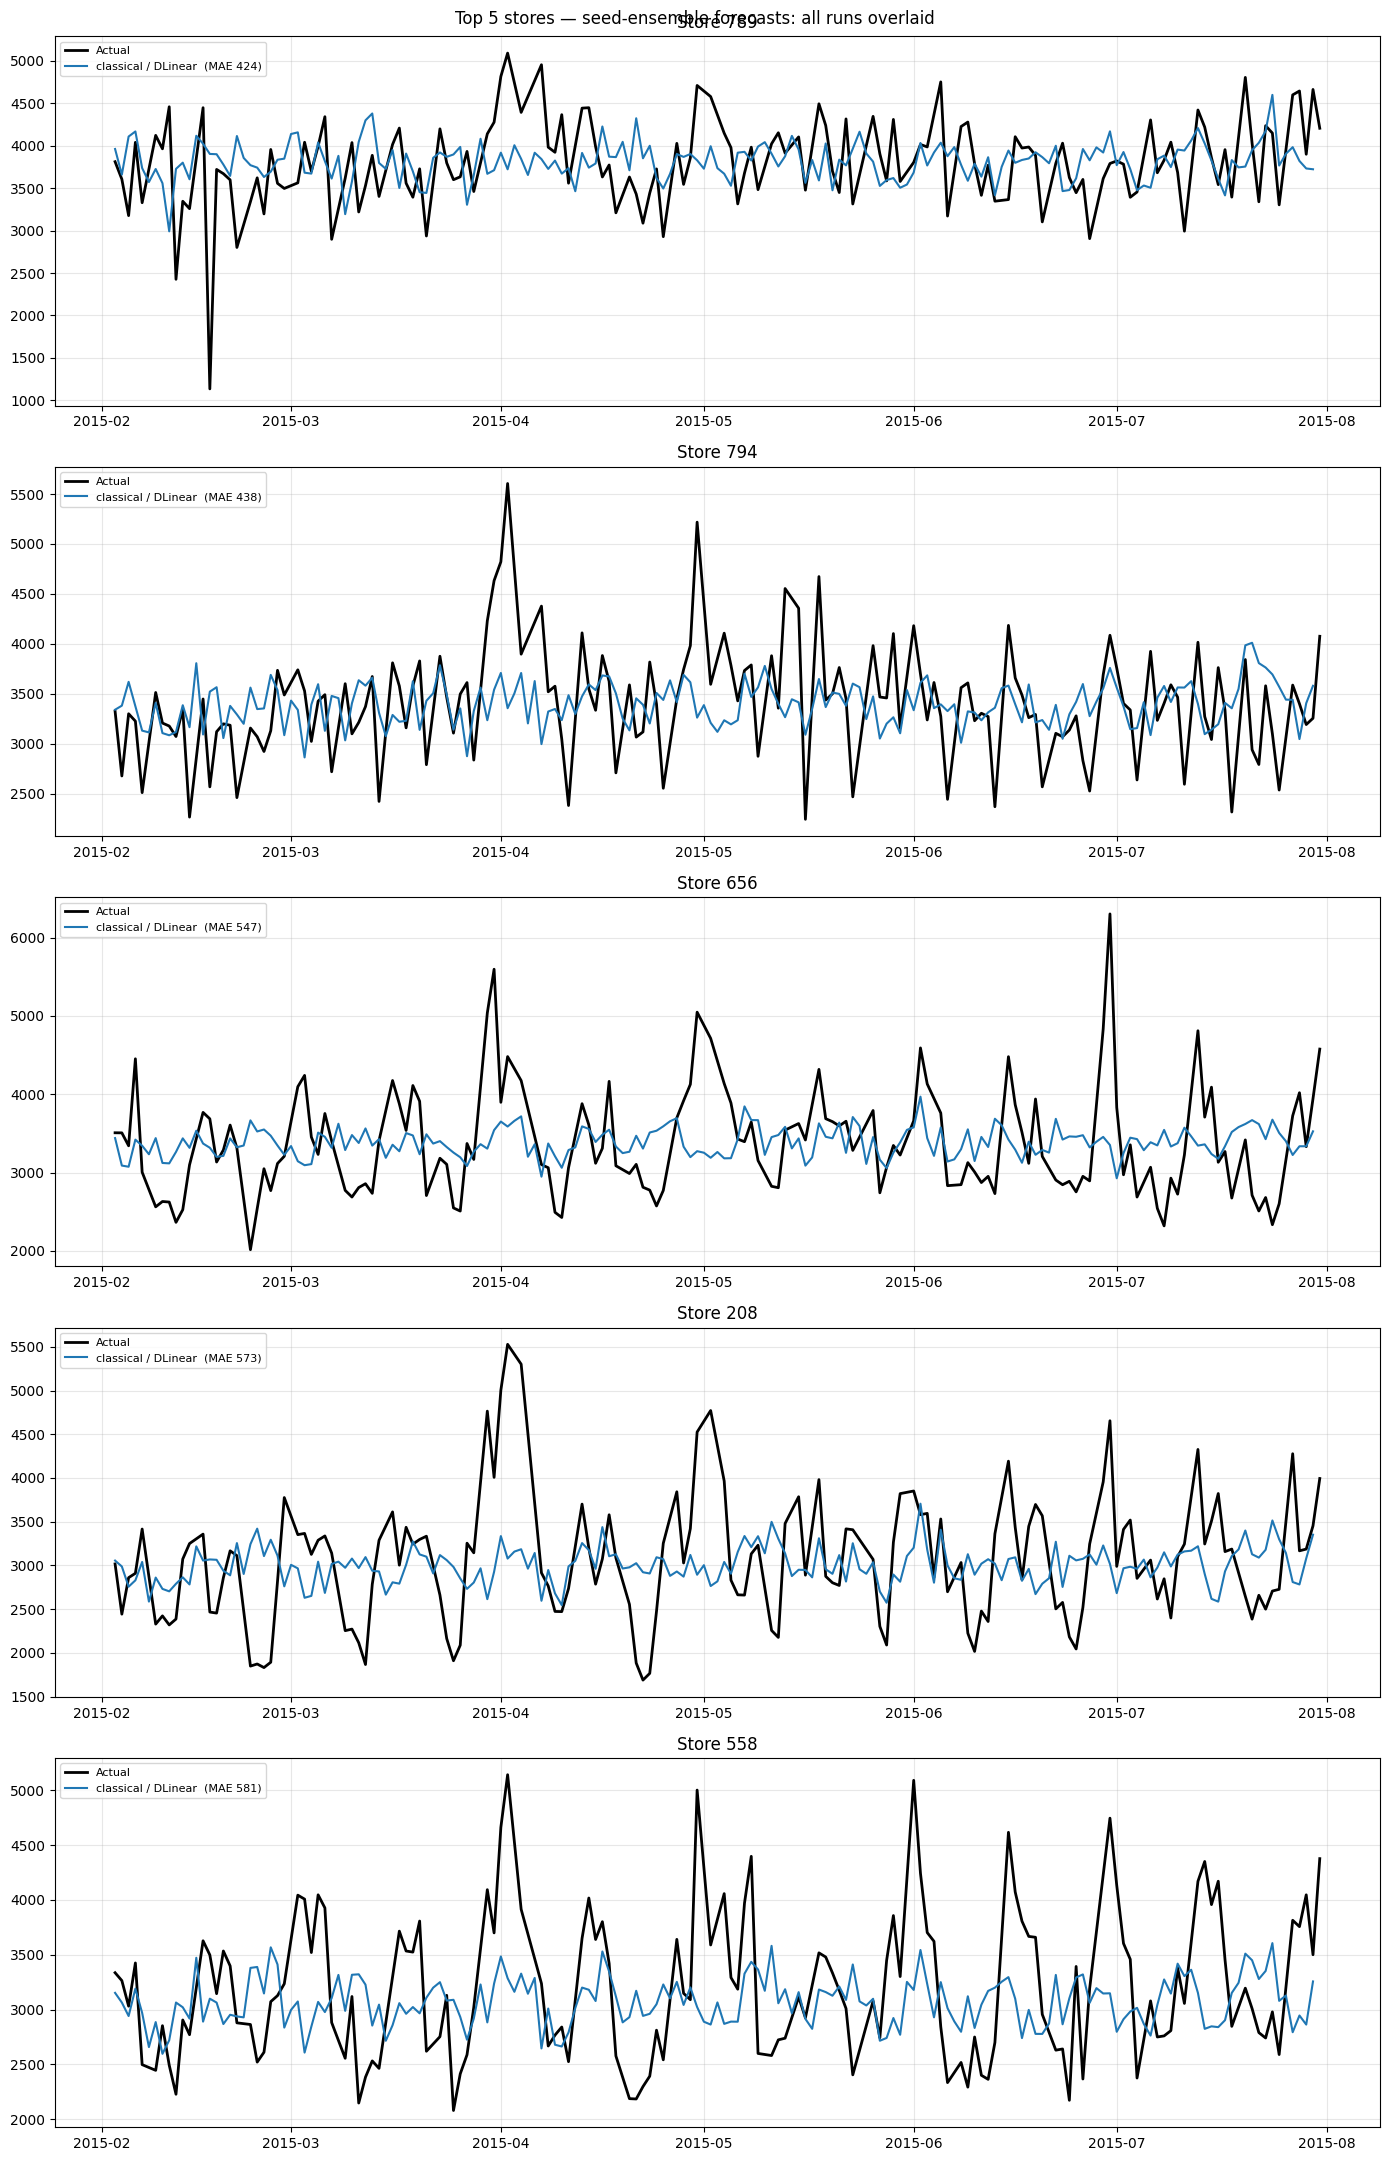

In [102]:
# ── Top 5 stores: all runs overlaid on the same subplot ──────────────────────
# Find the 5 stores with lowest average error across ALL runs combined.
all_store_errors = []
for run_label, avg_fc in all_avg_forecasts.items():
    model_cols = [c for c in avg_fc.columns if c not in ["Store", "Date"]]
    comp = test_df[["Store", "Date", "Sales"]].merge(avg_fc, on=["Store", "Date"], how="inner")
    comp["_err"] = sum((comp["Sales"] - comp[m]).abs() for m in model_cols) / len(model_cols)
    all_store_errors.append(comp[["Store", "_err"]])

combined_errors = pd.concat(all_store_errors).groupby("Store")["_err"].mean()
top_5 = combined_errors.sort_values().head(5).index.tolist()
print(f"\nTop 5 stores (lowest avg error across all runs): {top_5}")

# One subplot per store; all runs × models overlaid with distinct line styles
linestyles = ["-", "--", "-.", ":"]
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=False)
fig.suptitle("Top 5 stores — seed-ensemble forecasts: all runs overlaid", fontsize=12)

for i, store_id in enumerate(top_5):
    ax = axes[i]
    # Actual sales (from any run's comparison — they all have the same test_df)
    store_actual = test_df[test_df["Store"] == store_id].sort_values("Date")
    ax.plot(store_actual["Date"], store_actual["Sales"],
            label="Actual", color="black", linewidth=2)

    for r_idx, (run_label, avg_fc) in enumerate(all_avg_forecasts.items()):
        model_cols = [c for c in avg_fc.columns if c not in ["Store", "Date"]]
        store_fc = avg_fc[avg_fc["Store"] == store_id].sort_values("Date")
        if store_fc.empty:
            continue
        ls = linestyles[r_idx % len(linestyles)]
        for m_idx, model in enumerate(model_cols):
            color = colors[(r_idx * len(model_cols) + m_idx) % len(colors)]
            store_mae = (store_actual.set_index("Date")["Sales"]
                         .reindex(store_fc["Date"].values) - store_fc[model].values
                         ).abs().mean()
            ax.plot(store_fc["Date"], store_fc[model],
                    label=f"{run_label} / {model}  (MAE {store_mae:.0f})",
                    linestyle=ls, color=color, linewidth=1.5)

    ax.set_title(f"Store {store_id}")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
